In [359]:
import numpy as np
import matplotlib.pyplot as plt
import hcipy as hci
import pandas as pd

![Gemini_Generated_Image_jh67bjjh67bjjh67 (1).png](<attachment:Gemini_Generated_Image_jh67bjjh67bjjh67 (1).png>)
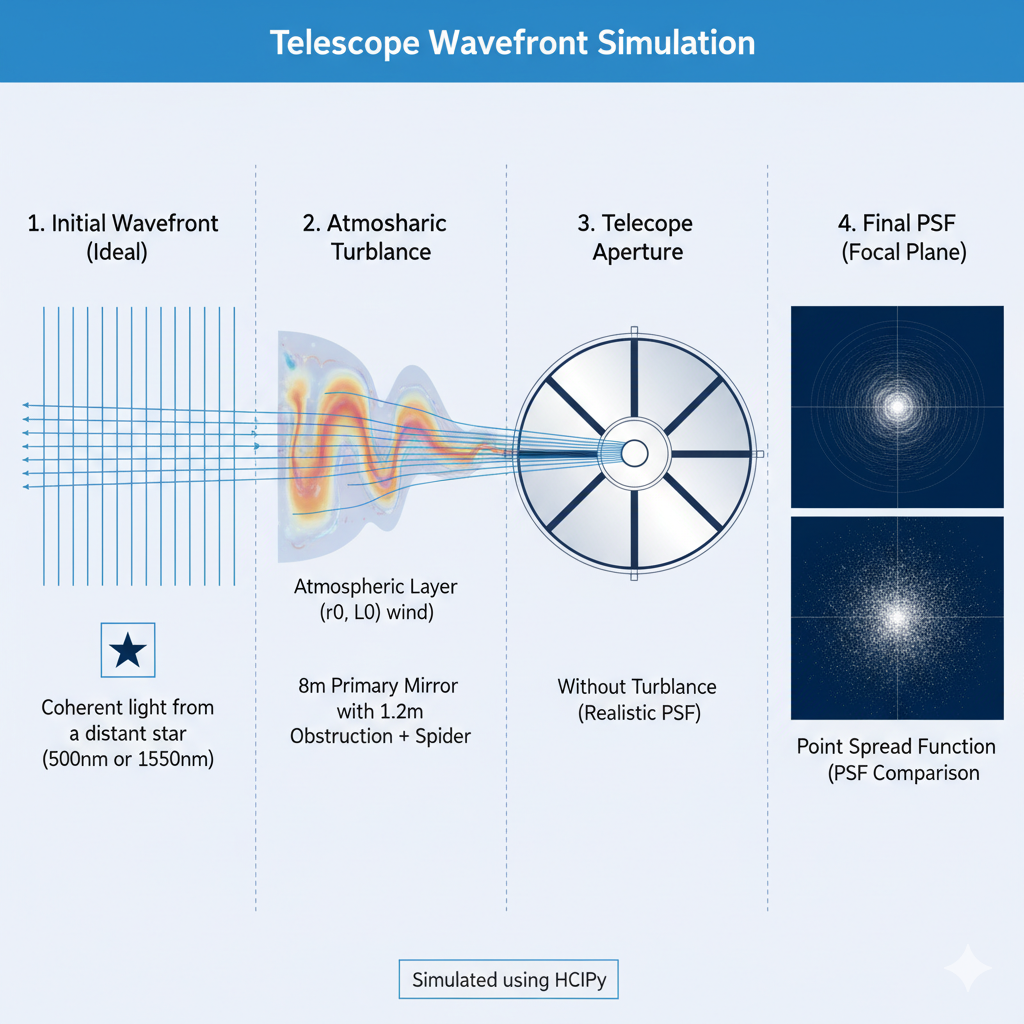

### pupil/ telescope params :
- telescope diam. 
- central obscuration : the diam. of the block in the middle of the pupil
- central obscuration ratio
- spider width : the arms/handles that hold the obscuration in place 
- oversizing factor : 

aperture params

In [360]:
wavelength = 500e-9
# wavelength = 1550e-9

# physical measurements
telescope_diameter = 8.0       # [m]
central_obscuration = 1.2      # [m]
central_obscuration_ratio = central_obscuration / telescope_diameter
spider_width = 0.05            # [m]

using the specifications to create the aperture generator :

- telescope diameter
- central obrcuration - circle in the center that is the view block of the mirror
- num spiders - the legs holding the mirror
- spider width - theyre width


In [361]:
VLT_aperture_generator = hci.make_obstructed_circular_aperture(
    telescope_diameter,
    central_obscuration_ratio,
    num_spiders=4,
    spider_width=spider_width
)

pupil grid params and instance

In [362]:
# simulation auxillary
oversizing_factor = 16.0 / 15.0
num_pupil_pixels_base = 240
num_pupil_pixels = int(num_pupil_pixels_base * oversizing_factor)  # must be int
pupil_grid_diameter = telescope_diameter * oversizing_factor
# pupil_grid = hci.make_pupil_grid(num_pupil_pixels_base, pupil_grid_diameter)
pupil_grid = hci.make_pupil_grid(num_pupil_pixels, pupil_grid_diameter)
pupil_grid.shape

array([256, 256])

focal grid params and instance

In [363]:
q = 4
num_airy = 50
focal_spatial_resolution = wavelength / telescope_diameter
focal_grid = hci.make_focal_grid(q=q, num_airy=num_airy, spatial_resolution=focal_spatial_resolution)
focal_grid.shape

array([400, 400])

creating an instance of an aperture field

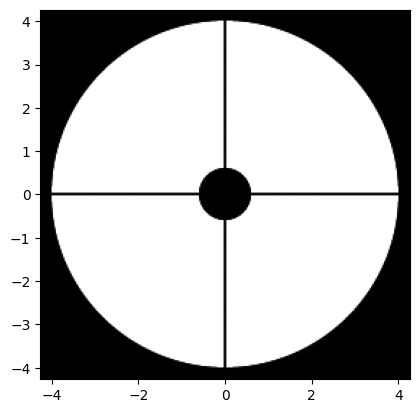

In [364]:
sampling_rate = 4
aperture = hci.evaluate_supersampled(VLT_aperture_generator,pupil_grid,4)
wf_aperture = hci.Wavefront(aperture,wavelength)
wf_aperture.total_power = 1.0
hci.imshow_field(wf_aperture.power,cmap = "gray")

propagate the wavefront through the pupil creates the psf

In [365]:
# wf_init = hci.Wavefront(np.ones_like(pupil_grid))
propagator = hci.FraunhoferPropagator(pupil_grid,focal_grid)
psf_aperture = propagator.forward(wf_aperture).power
psf_aperture.total_power = 1.0

C:\Users\ADMIN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\hcipy\fourier\naive_fourier_transform.py:168: RuntimeWarning: overflow encountered in scalar multiply
  num_complex_multiplications = input_grid.size * output_grid.size
C:\Users\ADMIN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\hcipy\fourier\naive_fourier_transform.py:169: RuntimeWarning: overflow encountered in scalar multiply
  num_complex_additions = (input_grid.size - 1) * output_grid.size
C:\Users\ADMIN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\hcipy\fourier\naive_fourier_transform.py:171: RuntimeWarning: overflow encountered in scalar multiply
  num_multiplications = 4 * num_complex_multiplications
C:\Users\ADMIN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p

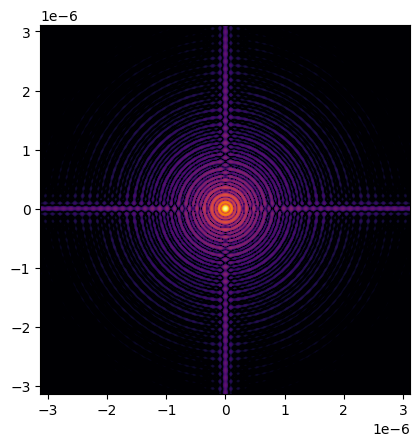

In [366]:
im = np.log10(psf_aperture/psf_aperture.max())
hci.imshow_field(im,cmap="inferno",vmin=-6,vmax=0)

atmosphere layer

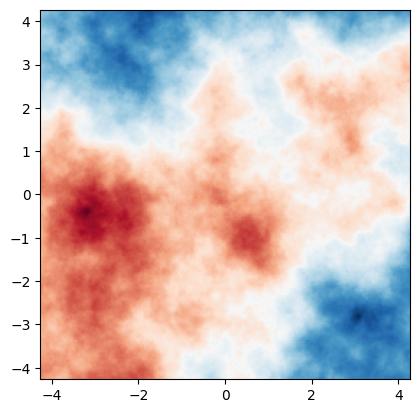

In [ ]:
r0 = 2.0
wavelength_ref = 500e-9
L0 = 50.0
r0_ref_500nm = r0 * (wavelength/wavelength_ref)**(6.0/5.0)
Cn2 = hci.Cn_squared_from_fried_parameter(r0_ref_500nm,wavelength)

atmosphere = hci.InfiniteAtmosphericLayer(pupil_grid,Cn2,L0=L0,velocity=0)
phase_screen = atmosphere.phase_for(wavelength)

hci.imshow_field(phase_screen,cmap= "RdBu")

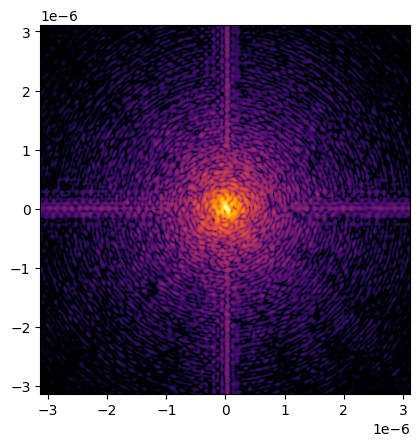

In [404]:
wf_turb = atmosphere(wf_aperture)
psf_turb = propagator.forward(wf_turb).power
psf_turb.total_power = 1.0
im = np.log10(psf_turb/psf_turb.max())
hci.imshow_field(im,cmap="inferno",vmin=-6,vmax=0)

In [385]:
df = pd.read_csv("./massive_output.csv")
df
cols = ["wavelength",
"r0_ref",
"run_number",

"power_in_bucket_before_turbulance",
"total_power_before_turbulance",
"precentage_before_turbulance",

"power_in_bucket_after_turbulance",
"total_power_after_turbulance",
"precentage_after_turbulance",

"time"
]
df.head()

,wavelength,r0_ref,run_number,power_in_bucket_before_turbulance,total_power_before_turbulance,precentage_before_turbulance,power_in_bucket_after_turbulance,total_power_after_turbulance,precentage_after_turbulance,time
0,0.000002,0.01,1,0.047627,0.989933,0.048111,0.047627,0.989933,0.048111,2025-10-18 00:12:26
1,0.000002,0.01,2,0.047627,0.989933,0.048111,0.047627,0.989933,0.048111,2025-10-18 00:12:29
2,0.000002,0.01,3,0.047627,0.989933,0.048111,0.047627,0.989933,0.048111,2025-10-18 00:12:33
3,0.000002,0.01,4,0.047627,0.989933,0.048111,0.047627,0.989933,0.048111,2025-10-18 00:12:36
4,0.000002,0.01,5,0.047627,0.989933,0.048111,0.047627,0.989933,0.048111,2025-10-18 00:12:39


In [386]:
def extract_wavelength_r0_results(wavelength = 0.5e-6):
    condition_wavelength = df["wavelength"] == wavelength
    data_wavelength = df[condition_wavelength] 

    r0_list = data_wavelength["r0_ref"]
    r0_list = sorted([item for item in set(r0_list)])

    before_precentage = []
    after_precentage = []
    for r0 in r0_list:
        current_r0_condition = data_wavelength["r0_ref"] == r0
        current_r0_rows = data_wavelength[current_r0_condition]
        print(current_r0_rows["precentage_after_turbulance"].mean())
        before_precentage.append(current_r0_rows["precentage_before_turbulance"].mean())
        after_precentage.append(current_r0_rows["precentage_after_turbulance"].mean())
    result = {
        "r0" : r0_list,
        "before_precentage" : before_precentage,
        "after_precentage" : after_precentage
    }
    return result

In [387]:
results_1550nm = extract_wavelength_r0_results(1.55e-06)
results_500nm = extract_wavelength_r0_results(0.5e-06)

0.002416337165506788
0.00020331506834248594
0.00039870551359338187
0.0010509772012250174
0.0039715192864104
0.003310540377434684
0.00195251687547609
0.00454541795981528
0.004582100397968381
0.00716109732199118
0.022108952209145702
1.1592278647819244e-05
1.9254638616091506e-05
1.6247946854677335e-05
1.022276361167909e-05
2.9533661366144843e-05
2.221234309679341e-05
2.223989047250009e-05
1.7229169177634023e-05
3.919376377457913e-05
2.8031390384931694e-05


[0.02555556 0.04111111 0.05666667 0.07222222 0.08777778 0.10333333
 0.11888889 0.13444444 0.15      ]
[0.00020331506834248594, 0.00039870551359338187, 0.0010509772012250174, 0.0039715192864104, 0.003310540377434684, 0.00195251687547609, 0.00454541795981528, 0.004582100397968381, 0.00716109732199118]


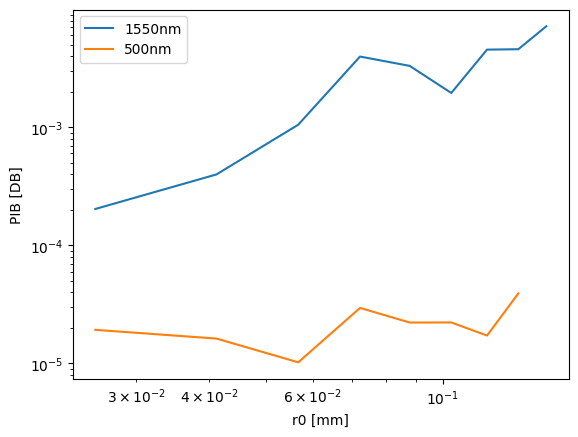

In [388]:
start = 1
end = -1
after_1550nm = results_1550nm["after_precentage"][start:end]
axis_1550nm = np.array(results_1550nm["r0"][start:end])
# axis_1550nm = axis_1550nm/axis_1550nm.max()

after_500nm = results_500nm["after_precentage"][start:end]
axis_500nm = np.array(results_500nm["r0"][start:end])
# axis_500nm = axis_500nm/axis_500nm.max()

print(axis_1550nm)
print(after_1550nm)
plt.loglog(axis_1550nm,[i for i in after_1550nm])
plt.loglog(axis_500nm,[i for i in after_500nm])
# plt.plot(axis_1550nm,[np.log10(i) for i in after_1550nm])
# plt.plot(axis_500nm,[np.log10(i) for i in after_500nm])
plt.ylabel("PIB [DB]")
plt.xlabel("r0 [mm]")
plt.legend(["1550nm","500nm"])

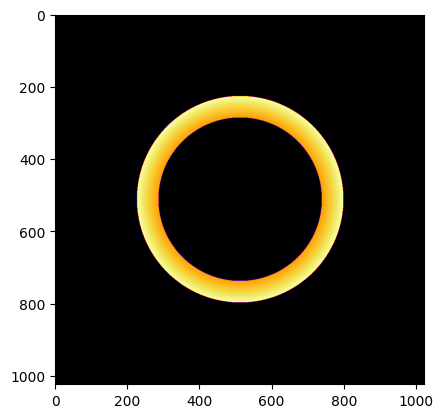

In [389]:
N = 256 *4
circle = np.zeros((N,N))
center = N // 2
R = center // 2
width = 30

for i in range(N):
    for j in range(N):
        r = np.sqrt((center-i)**2 + (center-j)**2)
        if R - width <= r <= R + width:
            circle[i,j] = r

plt.imshow(circle, cmap="inferno")